### Libraries

In [8]:
import os
import numpy as np
import nibabel as nb
import pandas as pd
import glob
import matplotlib.pyplot as plt
import enigmatoolbox
#reload(enigmatoolbox)
#import enigmatoolbox
from enigmatoolbox.plotting import plot_cortical
from enigmatoolbox.utils.parcellation import parcel_to_surface
from enigmatoolbox.utils.parcellation import surface_to_parcel
from enigmatoolbox.datasets import load_sc, load_fc
from nilearn import plotting
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainstat.datasets import fetch_mask
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from brainspace.datasets import load_mask
from brainspace.utils.parcellation import map_to_labels
import scipy.stats as stats
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation
import networkx as nx
from igraph import Graph
import copy
import cmocean
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from brainspace.null_models import SpinPermutations
from scipy.stats import spearmanr
from scipy.stats import pearsonr

### Load surfaces and masks

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPE surf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR masks
mask_32k = load_mask(join=True)

# Load fsaverage5
fs5_lh = read_surface(micapipe+'/surfaces/fsaverage5/surf/lh.pial', itype='fs')
fs5_rh = read_surface(micapipe+'/surfaces/fsaverage5/surf/rh.pial', itype='fs')
fs5_mask = fetch_mask("fsaverage5")

# Load fsaverage5 inflated surfaces and mask
#fs5_lh = read_surface(micapipe+'/surfaces/fsaverage5/surf/lh.inflated', itype='fs')
#fs5_rh = read_surface(micapipe+'/surfaces/fsaverage5/surf/rh.inflated', itype='fs')
#fs5_mask = fetch_mask("fsaverage5")

### Load cortico-cortical structural connectivity data

In [97]:
# Load CSV file containing subject and session information
csv_dir = '/host/percy/local_raid/youngeun/from_mica1/lists'
csv_file = f"10PNC_T1map.csv"
subject_session_info = pd.read_csv(csv_dir + '/' + csv_file, header=None, names=['info'], delimiter=',')

# Extract subject and session information from each row
files = []
for index, row in subject_session_info.iterrows():
    info = row['info'].split(',')
    subject = index[4:]  # Extract subject ID
    session = info[0][4:].strip()  # Extract session ID
    files_sc = f"sub-{subject}/ses-01/dwi/connectomes/*_surf-fsLR-5k_desc-iFOD2-40M-SIFT2_full-connectome.shape.gii"
    files.extend(glob.glob(files_sc))

# Load intensity profiles from each file
profiles = []
for file_path in files:
    profile_data = nb.load(file_path).darrays[0].data
    profiles.append(profile_data)
profiles = np.array(profiles)
sc = np.mean(profiles, axis=0)
sc_sym = np.triu(sc,1)+sc.T

In [98]:
profiles.shape

(10, 9684, 9684)

### Load cortical connectivity matrices¶

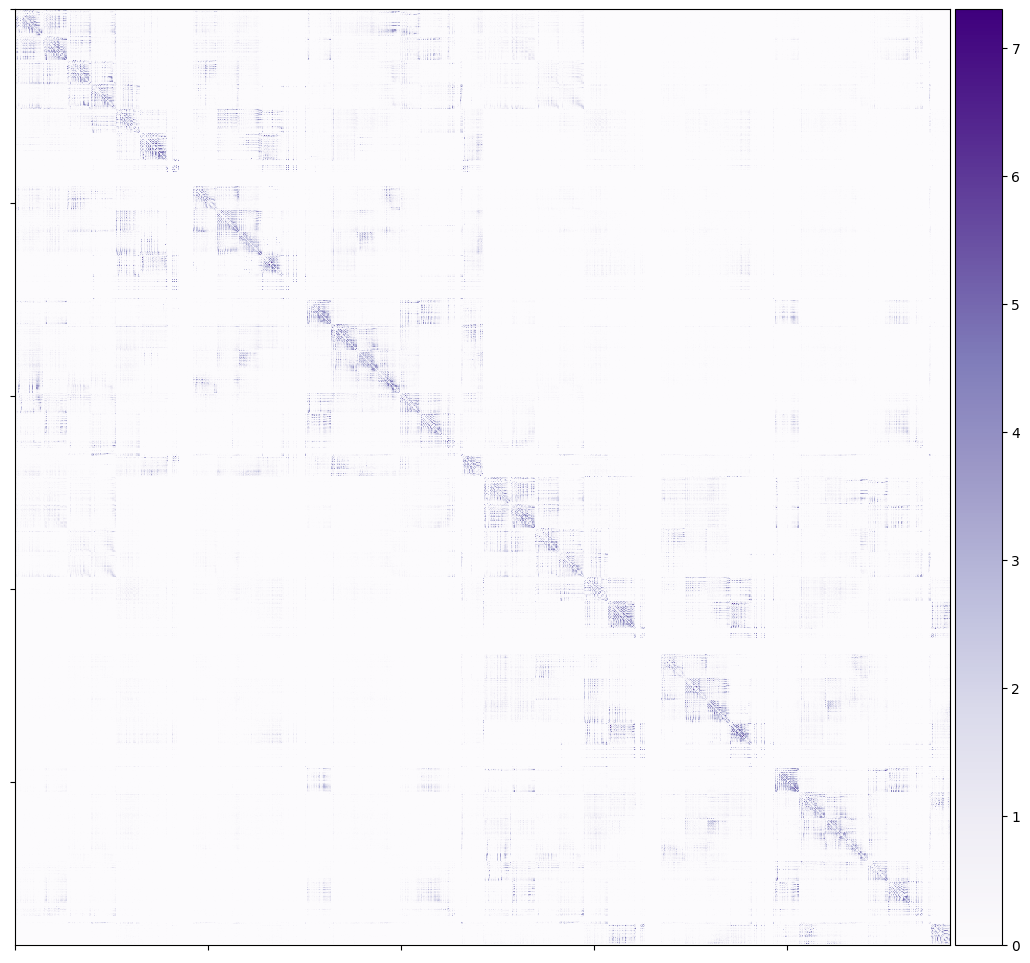

In [112]:
# Plot cortico-cortical connectivity matrices
sc_plot = plotting.plot_matrix(np.log(sc_sym+1), figure=(10, 10), labels=None, cmap='Purples')

## Structural connectivity 

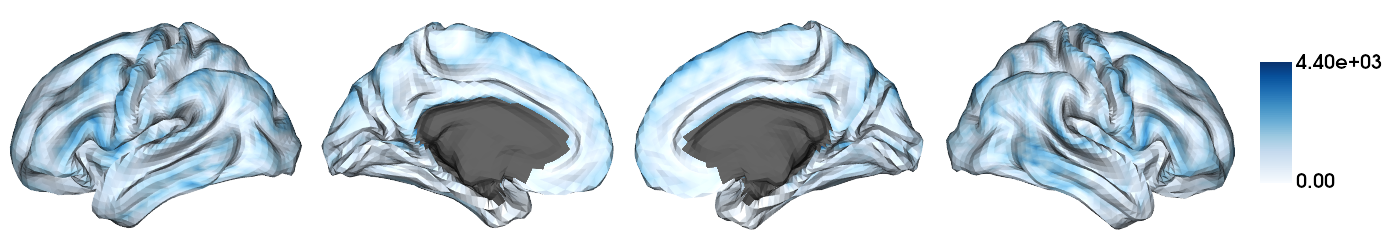

In [113]:
# Consider the absolute value
#sc_abs = np.abs(sc_sym)
sc_abs = np.log(sc_sym+1)

# Compute weighted degree centrality measures from the connectivity data
sc_ctx = np.sum(sc_abs, axis=0)

sc_ctx[mask_5k == False] = np.nan

plot_hemispheres(f5k_lh, f5k_rh, sc_ctx, cmap='Blues', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

### Load intensity profiles

In [6]:
# Load GM intensity profiles
T1map_mid_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/T1map_mid_int_10sub.npy')
T1map_swm_int = np.flip(np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_swmIP.npy'), axis=0)
T1map_swm_1mm = T1map_swm_int[5,:]
T1map_swm_2mm = T1map_swm_int[10,:]
T1map_swm_3mm = T1map_swm_int[15,:]

# Load GM intensity profiles
MTSAT_mid_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/MTSAT_mid_int_10sub.npy')
MTSAT_swm_int = np.flip(np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_swmIP.npy'), axis=0)
MTSAT_swm_1mm = MTSAT_swm_int[5,:]
MTSAT_swm_2mm = MTSAT_swm_int[10,:]
MTSAT_swm_3mm = MTSAT_swm_int[15,:]

## Spin permutations structural connectivity ~ SWM feature

In [9]:
# Shape of the fsLR-5k matrices
#N32k = 64984
N5k = 9684

# Load spheres fsLR5k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-5k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-5k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

In [120]:
def plot_spin_permutations(sub_id, qmri):

    ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-01/dwi/connectomes/*_surf-fsLR-5k_desc-iFOD2-40M-SIFT2_full-connectome.shape.gii")[0]
    fdata = nb.load(ffile_path).darrays[0].data
    
    fc_sym = np.triu(fdata,1)+fdata.T
    fc_abs = np.log(fc_sym+1)
    fc_ctx = np.sum(fc_abs, axis=0) 

    fdata_L = fc_ctx[0:int(N5k/2)]
    fdata_R = fc_ctx[int(N5k/2):N5k]

    # Load SWM intensity profile data
    sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_surf-fsLR-5k_desc-MPC.shape.gii")[0]
    swm_data = nb.load(sfile_path).darrays[0].data
    
    # Get the SWM values from 1mm below WM
    swm_1mm = swm_data[5, :]
    swm_2mm = swm_data[10, :]
    swm_3mm = swm_data[15, :]
    
    # Spin permutation on full data (Get the rotated data)
    func_rotated = np.hstack(spinp.randomize(fdata_L, fdata_R))
    
    swms = {'SWM 1mm': swm_1mm, 'SWM 2mm': swm_2mm, 'SWM 3mm': swm_3mm}
    
    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    
    for k, (fn, swm) in enumerate(swms.items()):

        mask = ~np.isnan(fc_ctx) & ~np.isnan(swm)
        non_zero_mask = ~((fc_ctx[mask] == 0) & (swm[mask] == 0))
        valid_fc = fc_ctx[mask][non_zero_mask]
        valid_swm = swm[mask][non_zero_mask]
        
        # Observed correlation
        r_obs, p_obs = spearmanr(fc_ctx[mask][non_zero_mask], swm[mask][non_zero_mask])
        
        # Permutation-based correlations
        r_spin = np.array([spearmanr(perm[mask][non_zero_mask], swm[non_zero_mask])[0] for perm in func_rotated])
        p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
        
        # Plot null distribution
        axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.6, .6, .6))
        axs[k].axvline(r_obs, lw=2, ls='--', color='k')
        axs[k].set_xlabel(f'Correlation with {fn}')
        if k == 0:
            axs[k].set_ylabel('Density')
        #textstr = f'Obs: r = {r_obs:.3f}, p = {p_obs:.3f}\nSpin: r = {np.mean(r_spin):.3f}, p = {p_spin:.3f}'
        textstr = f"r = {r_obs:.3f}, $P_{{spin}}$ = {p_spin:.3f}"
        axs[k].text(0.95, 0.95, textstr, transform=axs[k].transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))
    
    fig.tight_layout()
    plt.show()

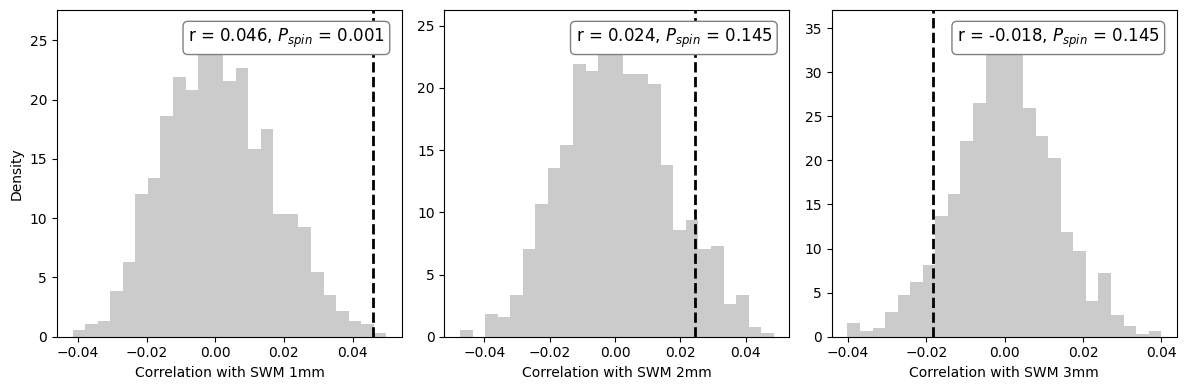

In [131]:
plot_spin_permutations(sub_id="07", qmri="MTSAT_protocol")

In [116]:
def plot_str_swm_correlation(sub_id, qmri):
    try:
        # Load curvature data (left & right hemispheres)
        #ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-03/func/desc-me_task-rest_bold/surf/*_surf-fsLR-32k_atlas-schaefer-400_desc-FC.shape.gii")[0]
        ffile_path = glob.glob(f"/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC0{sub_id}/ses-01/dwi/connectomes/*_surf-fsLR-5k_desc-iFOD2-40M-SIFT2_full-connectome.shape.gii")[0]
        fdata = nb.load(ffile_path).darrays[0].data
        
        fc_sym = np.triu(fdata,1)+fdata.T
        # Consider the absolute value
        fc_abs = np.log(fc_sym+1)
        # Compute weighted degree centrality measures from the connectivity data
        fc_ctx = np.sum(fc_abs, axis=0) 
        # Map parcellated data to the surface
        #fc_ctx_dc = parcel_to_surface(fc_abs, 'schaefer-400_fsLR5k')
    
        fdata_L = fc_ctx[0:int(N5k/2)]
        fdata_R = fc_ctx[int(N5k/2):N5k]
    
        # Load SWM intensity profile data
        #sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_atlas-schaefer-400_desc-intensity_profiles.shape.gii")[0]
        sfile_path = glob.glob(f"sub-PNC0{sub_id}/ses-03/mpc-swm/acq-{qmri}/*_surf-fsLR-5k_desc-MPC.shape.gii")[0]
        swm_data = nb.load(sfile_path).darrays[0].data
        #swm_noMW = np.delete(swm_data, [0, 201], axis=1)
        
        # Get the SWM values from 1mm below WM
        swm_1mm = swm_data[5, :]
        swm_2mm = swm_data[10, :]
        swm_3mm = swm_data[15, :]
        #swm_1mm_dc = parcel_to_surface(swm_1mm, 'schaefer-400_fsLR5k')
        #swm_2mm_dc = parcel_to_surface(swm_2mm, 'schaefer-400_fsLR5k')
        #swm_3mm_dc = parcel_to_surface(swm_3mm, 'schaefer-400_fsLR5k')
        
        swms = {'SWM 1mm': swm_1mm, 'SWM 2mm': swm_2mm, 'SWM 3mm': swm_3mm}
        
        # Plotting
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))

        for k, (fn, swm) in enumerate(swms.items()):
            mask = ~np.isnan(fc_ctx) & ~np.isnan(swm)
            non_zero_mask = ~((fc_ctx[mask] == 0) & (swm[mask] == 0))
            valid_fc = fc_ctx[mask][non_zero_mask]
            valid_swm = swm[mask][non_zero_mask]
                
            r, p = sp.stats.spearmanr(valid_fc, valid_swm)

            df = pd.DataFrame({'Functional Strength': valid_fc, f'{qmri} intensity': valid_swm})
            sns.regplot(
                x='Functional Strength', y=f'{qmri} intensity', data=df, ax=axs[k],
                scatter_kws={'color': '#A9A9A9', 'alpha': 0.7},  # 밝은 회색
                line_kws={'color': '#5072A7', 'linewidth': 3}  # Royal Blue
            )
            #axs[k].set_title(f'{fn}\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_title(f'SC vs. T1 map\n$(r$ = {r:.2f}, $P_{{obs}}$ = {p:.3f})', fontsize=20)
            axs[k].set_xlabel('Structural Connectivity', fontsize=16)
            axs[k].set_ylabel(f'{qmri} Intensity', fontsize=16)
            axs[k].grid(True, linestyle='--', linewidth=0.5)

        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f"Unexpected error: {e}")


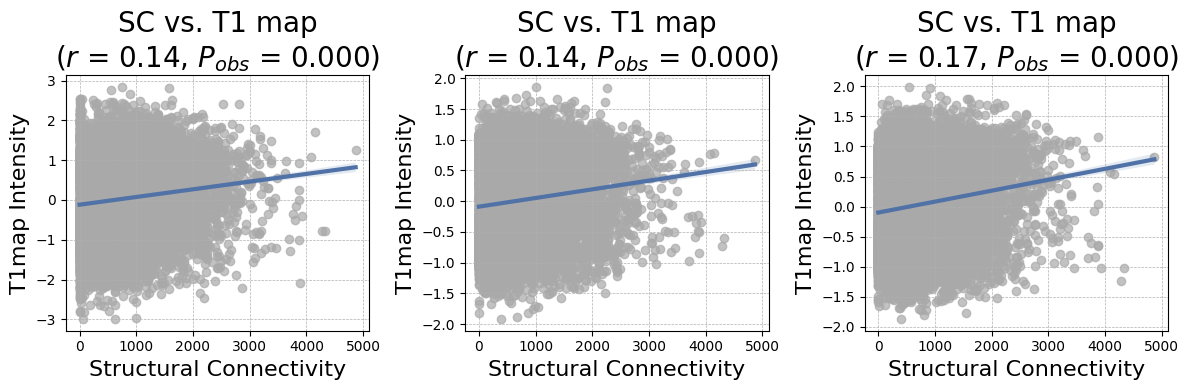

In [117]:
plot_str_swm_correlation(sub_id="03", qmri="T1map")